In [1]:
!pip install tensorflow
import tensorflow as tf
from tensorflow.keras import layers, models

# Configuration
BATCH_SIZE = 32
IMG_SIZE = (224, 224) # Standard size for many architectures
DATA_DIR = "dataset" 

# Loading the dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary' # Important for Real/Fake binary tasks
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

# Optimize performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 32 files belonging to 2 classes.
Using 26 files for training.
Found 32 files belonging to 2 classes.
Using 6 files for validation.


In [2]:
model = models.Sequential([
    # Preprocessing: Rescale pixel values from [0, 255] to [0, 1]
    layers.Rescaling(1./255, input_shape=(224, 224, 3)),
    
    # Feature Extraction
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Classification Head
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Prevents overfitting
    layers.Dense(1, activation='sigmoid') # Binary output
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/opt/miniconda3/envs/myenv/lib/python3.11/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [3]:
# Training
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)



Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5769 - loss: 0.6764 - val_accuracy: 0.5000 - val_loss: 2.3584
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.5000 - loss: 1.5517 - val_accuracy: 0.5000 - val_loss: 3.9270
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 0.4615 - loss: 4.3878 - val_accuracy: 0.5000 - val_loss: 0.8910
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.5385 - loss: 1.1756 - val_accuracy: 1.0000 - val_loss: 0.1711
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 0.9231 - loss: 0.3185 - val_accuracy: 0.5000 - val_loss: 0.7676
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 0.9231 - loss: 0.3454 - val_accuracy: 0.6667 - val_loss: 0.3507
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - accuracy: 0.9231 - loss: 0.2199 - val_accuracy: 1.0000 - val_loss: 0.0467
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step - accuracy: 0.9615 - loss: 0.0866 - val_accuracy: 1.0000 - val_loss: 0.

In [4]:
# Predicting a single image
import numpy as np

def predict_real_or_fake(img_path):
    img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0) # Create batch axis
    prediction = model.predict(img_array)
    
    if prediction[0] > 0.5:
        print(f"Result: REAL (Confidence: {prediction[0][0]:.2f})")
    else:
        print(f"Result: FAKE (Confidence: {1 - prediction[0][0]:.2f})")


predict_real_or_fake("dataset/real/KFS Image V1.0_page-0017-removebg-preview.jpg")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Result: REAL (Confidence: 0.84)


In [5]:
# After training your 'model'...
model.save('trained_model.keras')

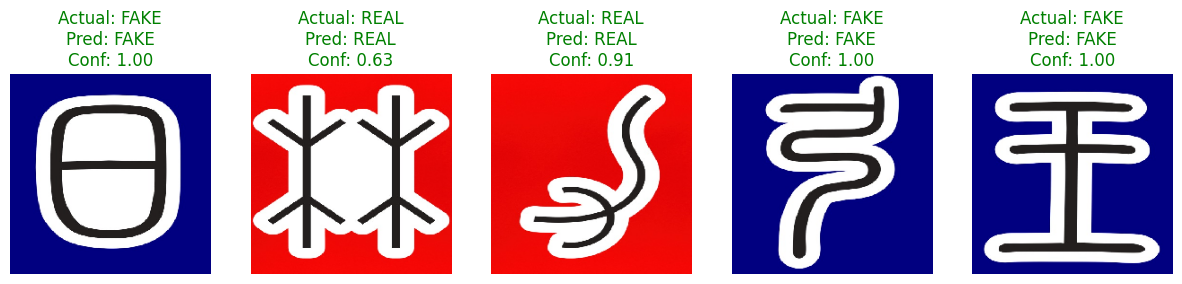

In [35]:
# Verification: Actual vs Predicted
import os
import random
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# Define IMG_SIZE if not already defined (fallback)
try:
    IMG_SIZE
except NameError:
    IMG_SIZE = (224, 224)

def verify_random_images(model, dataset_path, num_images=5):
    real_path = os.path.join(dataset_path, 'real')
    fake_path = os.path.join(dataset_path, 'fake')
    
    real_images = [os.path.join(real_path, img) for img in os.listdir(real_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
    fake_images = [os.path.join(fake_path, img) for img in os.listdir(fake_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    all_images = [(img, 'REAL') for img in real_images] + [(img, 'FAKE') for img in fake_images]
    
    if not all_images:
        print("No images found for verification.")
        return

    selected_images = random.sample(all_images, min(len(all_images), num_images))
    
    plt.figure(figsize=(15, 10))
    for i, (img_path, actual_label) in enumerate(selected_images):
        # Load image
        img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
        img_array = tf.keras.utils.img_to_array(img)
        img_batch = tf.expand_dims(img_array, 0)
        
        # Predict
        prediction = model.predict(img_batch, verbose=0)
        score = prediction[0][0]
        
        predicted_label = "REAL" if score > 0.5 else "FAKE"
        confidence = score if score > 0.5 else 1 - score
        
        color = 'green' if actual_label == predicted_label else 'red'
        
        ax = plt.subplot(1, num_images, i + 1)
        # Convert PIL image to array for display if needed, or just use img_array/255.0
        # img_array is float32 (0-255) usually if not rescaled yet.
        # But load_img returns PIL image. 
        # imshow handles PIL images directly.
        # The previous error 'astype' was because 'img' is PIL Image.
        plt.imshow(img) 
        plt.title(f"Actual: {actual_label}\nPred: {predicted_label}\nConf: {confidence:.2f}", color=color)
        plt.axis("off")
    plt.show()

# Run verification
verify_random_images(model, "dataset")
